<a href="https://colab.research.google.com/github/DS-Ninja/Dmitrij-Levyj/blob/Main/2%23%20Project%20-%20Scraping%20Job%20Offers%20from%20CVDatabase%3A%20Analyzing%20Popular%20Job%20Roles%2C%20Required%20Skills%2C%20and%20Creating%20a%20Tailored%20Study%20Plan%20part%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


---
---

<center>

#2# Project - Scraping Job Offers from CVDatabase: Analyzing Popular Job Roles, Required Skills, and Creating a Tailored Study Plan

</center>

---




---

```
Author
Dmitrij Levyj | "Details Matter"
```



<center>

---

[![WhatsApp](https://img.shields.io/badge/Whatsapp-Blue?style=social&logo=Whatsapp)](https://call.whatsapp.com/voice/WAl0Hu47THhpnB7d2mimjf)
[![Messenger](https://img.shields.io/badge/Messenger-Blue?style=social&logo=Messenger)](https://m.me/dimitrioespanol)
[![LinkedIn](https://img.shields.io/badge/LinkedIn-Blue?style=social&logo=linkedin)](https://www.linkedin.com/in/dmitrij-levyj)
[![GitHub](https://img.shields.io/badge/GitHub-Blue?style=social&logo=github)](https://github.com/DS-Ninja/Dmitrij-Levyj)
[![Kaggle](https://img.shields.io/badge/Kaggle-Blue?style=social&logo=kaggle)](https://www.kaggle.com/dmitrijlevyj)
[![Tableau](https://img.shields.io/badge/Tableau-Blue?style=social&logo=Tableau)](https://public.tableau.com/app/profile/dmitrij.levyj)

</center>











---

#**Table of Contents**


* **1. Introduction**
* **2. Data preparation**
    * 2.1 Importing Libraries
    * 2.2 Uploading data
    * 2.3 Translate Lithuanian to English in Description
    * 2.4 Standardize Salary to a Single Integer Value
    * 2.5 Check for missing values in the 'Average Salary (EUR)' column
    * 2.6 Function to fix improperly formatted salaries
    * 2.7 Calculate the median salary for each job position and fill missing values based on the position.
    * 2.8 Saving back up file
    * 2.9 Cleaning Position Names
    * 2.10 Normalize data
    * 2.11 Correct Standardized Position According to Job Description

* **3. Data Mining + Vis**
    * 3.1 Find the Most Popular Position Offer and Plot a Graph
    * 3.2 Find the Highest-Paying Job and Plot a Graph
    * 3.3 Find the Most-Required Skills/Tools

---


#1.Introduction

This project aims to analyze job market trends by scraping job offers from the CVDatabase platform. The primary objectives are to identify the most popular job roles, assess salary trends, and understand the skills and requirements in demand. The insights from this analysis will help create a tailored study plan to address the skills needed for the most sought-after roles.
Key Steps in the Project:

  * Data Collection:
        Scraping job offers, including details such as job title, salary, and description.

  * Data Processing:
        Translating job descriptions from Lithuanian to English for broader analysis.
        Cleaning and standardizing salary information to compute average values for better comparison.

  * Data Analysis:
        Identifying the most popular job roles based on occurrence frequency.
        Highlighting the roles with the highest salaries.
        Extracting skills and requirements for the top roles to align with industry needs.

  * Study Plan Creation:
        Designing a study plan based on the skills and qualifications required for the most popular and lucrative positions.

Outcome:

By the end of this analysis, the notebook will provide actionable insights into the job market and a clear roadmap for upskilling to meet current demands. This project serves as a foundation for anyone looking to align their skills with market trends and optimize their career growth.

#2.Data preparation

##2.1 Importing Libraries

In [13]:
# Import all necessary libraries
import pandas as pd          # For data manipulation and analysis
import re                    # For handling and parsing salary strings
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

##2.2 Uploading data

In [19]:
# Load the uploaded CSV file into a DataFrame
file_path = '/content/job_details.csv'  # Update this if your file has a different name
job_details = pd.read_csv(file_path)

# Display the DataFrame
print(job_details.head())

                                   Position Salary (EUR)  \
0                     IT SUPPORT SPECIALIST    1700-2100   
1     Full-Stack programuotojas (kainos.lt)     Nuo 4000   
2    Full-Stack programuotojas (Aruodas.lt)     Nuo 4000   
3  Full-Stack programuotojas (Autoplius.lt)     Nuo 4000   
4                      Virtualus asistentas       6,35-7   

                                         Description  
0  Job description\nProvide technical support to ...  
1  Kodėl tai geriausias darbas programuotojui?\nP...  
2  Kodėl tai geriausias darbas programuotojui?\nP...  
3  Kodėl tai geriausias darbas programuotojui?\nP...  
4  Darbo pobūdis\nIeškome virtualaus asistento įv...  


In [20]:
job_details

,Position,Salary (EUR),Description
0,IT SUPPORT SPECIALIST,1700-2100,Job description\nProvide technical support to ...
1,Full-Stack programuotojas (kainos.lt),Nuo 4000,Kodėl tai geriausias darbas programuotojui?\nP...
2,Full-Stack programuotojas (Aruodas.lt),Nuo 4000,Kodėl tai geriausias darbas programuotojui?\nP...
3,Full-Stack programuotojas (Autoplius.lt),Nuo 4000,Kodėl tai geriausias darbas programuotojui?\nP...
4,Virtualus asistentas,"6,35-7",Darbo pobūdis\nIeškome virtualaus asistento įv...
...,...,...,...
294,Product Management Specialist,2625-3937,Discover Impactful Work:\nAs a Product Managem...
295,Python Developer (for Chatbots),3000-4300,We believe in a world where the internet is wi...
296,Python Developer (for Operations),3000-4300,Ensuring top-notch assistance to every client ...
297,Mid JAVA programuotojas (-a),4300-5500,Jūsų atliekamos funkcijos būtų:\nTransporto va...


##2.3 Translate Lithuanian to English in Description


In [21]:
# Initialize the translator
translator = Translator()

# Define a function to translate Lithuanian text to English
def translate_description(text):
    if pd.notnull(text):  # Check if the text is not null
        try:
            translation = translator.translate(text, src='lt', dest='en')
            return translation.text
        except Exception as e:
            return f"Translation error: {e}"
    return text

# Apply the translation to the 'Description' column
job_details['Description (Translated)'] = job_details['Description'].apply(translate_description)

# Display the translated DataFrame
print(job_details[['Description', 'Description (Translated)']].head())


                                         Description  \
0  Job description\nProvide technical support to ...   
1  Kodėl tai geriausias darbas programuotojui?\nP...   
2  Kodėl tai geriausias darbas programuotojui?\nP...   
3  Kodėl tai geriausias darbas programuotojui?\nP...   
4  Darbo pobūdis\nIeškome virtualaus asistento įv...   

                            Description (Translated)  
0  Job Describe\nProvide Technical Support to Hot...  
1  Why is this the best job for the programmer?\n...  
2  Why is this the best job for the programmer?\n...  
3  Why is this the best job for the programmer?\n...  
4  The nature of the work\nWe are looking for vir...  


##2.4 Standardize Salary to a Single Integer Value

In [43]:
# Define a function to clean and calculate average salary
def process_salary(salary):
    if pd.isnull(salary):
        return None
    salary = salary.lower()
    # Handle salary ranges like "5000 - 6000"
    if '-' in salary:
        salary_range = re.findall(r'\d+', salary)
        if len(salary_range) == 2:
            return (int(salary_range[0]) + int(salary_range[1])) / 2
    # Handle "nuo" cases like "nuo 500"
    elif 'nuo' in salary:
        salary_value = re.search(r'\d+', salary)
        if salary_value:
            return int(salary_value.group())
    # Handle single values
    else:
        salary_value = re.search(r'\d+', salary)
        if salary_value:
            return int(salary_value.group())
    return None

# Apply the salary processing function
job_details['Average Salary (EUR)'] = job_details['Salary (EUR)'].apply(process_salary)

# Display the updated DataFrame
print(job_details[['Salary (EUR)', 'Average Salary (EUR)']].head())

  Salary (EUR)  Average Salary (EUR)
0    1700-2100                1900.0
1     Nuo 4000                4000.0
2     Nuo 4000                4000.0
3     Nuo 4000                4000.0
4       6,35-7                   NaN


##2.5 Check for missing values in the 'Average Salary (EUR)' column

In [97]:
# Check for missing values in the 'Average Salary (EUR)' column
missing_salaries = job_details[job_details['Average Salary (EUR)'].isnull()]
print(f"Rows with missing salaries: {len(missing_salaries)}")
print(missing_salaries[['Salary (EUR)', 'Average Salary (EUR)']])

# Check for unusual values (e.g., very low or very high salaries)
low_salaries = job_details[job_details['Average Salary (EUR)'] < 100]
high_salaries = job_details[job_details['Average Salary (EUR)'] > 50000]  # Example threshold

print(f"Rows with low salaries: {len(low_salaries)}")
print(low_salaries[['Salary (EUR)', 'Average Salary (EUR)']])

print(f"Rows with high salaries: {len(high_salaries)}")
print(high_salaries[['Salary (EUR)', 'Average Salary (EUR)']])

# Verify the data type of the 'Average Salary (EUR)' column
print(f"Column data type: {job_details['Average Salary (EUR)'].dtype}")


Rows with missing salaries: 0
Empty DataFrame
Columns: [Salary (EUR), Average Salary (EUR)]
Index: []
Rows with low salaries: 0
Empty DataFrame
Columns: [Salary (EUR), Average Salary (EUR)]
Index: []
Rows with high salaries: 0
Empty DataFrame
Columns: [Salary (EUR), Average Salary (EUR)]
Index: []
Column data type: float64


##2.6 Function to fix improperly formatted salaries

In [45]:
# Function to fix improperly formatted salaries
def fix_salary_format(salary):
    if pd.notnull(salary) and ',' in salary:
        salary = salary.replace(',', '.')  # Replace commas with dots
        salary_range = re.findall(r'\d+\.\d+|\d+', salary)
        if len(salary_range) == 2:
            min_salary = float(salary_range[0]) * 1000
            max_salary = float(salary_range[1]) * 1000
            return (min_salary + max_salary) / 2
    return None

# Apply the fix to the specific row
job_details.loc[4, 'Average Salary (EUR)'] = fix_salary_format(job_details.loc[4, 'Salary (EUR)'])


##2.7 Calculate the median salary for each job position and fill missing values based on the position.

In [52]:
# Calculate the overall median salary
overall_median_salary = job_details['Average Salary (EUR)'].median()

# Fill remaining missing values with the overall median salary
job_details['Average Salary (EUR)'].fillna(overall_median_salary, inplace=True)

# Verify if all missing values are resolved
print(f"Remaining missing salaries: {job_details['Average Salary (EUR)'].isnull().sum()}")


Remaining missing salaries: 0


<ipython-input-52-01a5192878ed>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  job_details['Average Salary (EUR)'].fillna(overall_median_salary, inplace=True)


##2.8 Saving back up file

In [57]:
import pandas as pd
import datetime

# Generate a timestamped filename
timestamp = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
backup_file_path = f'/content/job_details_backup_{timestamp}.pkl'

# Save DataFrame as Pickle
job_details.to_pickle(backup_file_path)

print(f"Intermediate backup saved as: {backup_file_path}")


Intermediate backup saved as: /content/job_details_backup_20250109_223802.pkl


## 2.9 Cleaning Position Names

In [94]:
# Preview the data
print("Before cleaning:")
print(job_details['Position'].value_counts())


Before cleaning:
Position
it projektų vadovas                   5
full stack programuotojas             5
it inžinierius                        4
it project manager                    4
linux sistemų administratorius        4
                                     ..
it vadovas • elektronikos gamyba      1
rpa programuotoja                     1
full stack software engineer          1
lead software engineer & team lead    1
android programuotojas                1
Name: count, Length: 239, dtype: int64


In [96]:
# Initialize the translator
translator = Translator()

# Define a function to translate Lithuanian text to English
def translate_description(text):
    if pd.notnull(text):  # Check if the text is not null
        try:
            translation = translator.translate(text, src='lt', dest='en')
            return translation.text
        except Exception as e:
            return f"Translation error: {e}"
    return text

# Apply the translation to the 'Description' column
job_details['Position (Translated)'] = job_details['Position'].apply(translate_description)

# Display the translated DataFrame
print(job_details[['Position', 'Position (Translated)']].head())


                    Position  Position (Translated)
0      it support specialist  IT Support Specialist
1  full stack programuotojas  Full Stack Programmer
2  full stack programuotojas  Full Stack Programmer
3  full stack programuotojas  Full Stack Programmer
4       virtualus asistentas      virtual assistant


In [99]:
# Save intermediate backup
timestamp = pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')
job_details.to_pickle(f'/content/job_details_cleaned_{timestamp}.pkl')
print(f"Intermediate backup saved as job_details_cleaned_{timestamp}.pkl")

Intermediate backup saved as job_details_cleaned_20250110_025124.pkl


##2.10 Normalize data

In [100]:
# Step 1: Keep only the specified English columns
cleaned_df = job_details[['Description (Translated)', 'Average Salary (EUR)', 'Position (Translated)']]

# Step 2: Display the first few rows of the cleaned DataFrame
print(cleaned_df.head())

# Step 3: Save the cleaned data to a new CSV file
cleaned_df.to_csv('cleaned_job_data.csv', index=False)

# Step 4: Download the file:
from google.colab import files
files.download('cleaned_job_data.csv')


                            Description (Translated)  Average Salary (EUR)  \
0  Job Describe\nProvide Technical Support to Hot...                1900.0   
1  Why is this the best job for the programmer?\n...                4000.0   
2  Why is this the best job for the programmer?\n...                4000.0   
3  Why is this the best job for the programmer?\n...                4000.0   
4  The nature of the work\nWe are looking for vir...                6675.0   

   Position (Translated)  
0  IT Support Specialist  
1  Full Stack Programmer  
2  Full Stack Programmer  
3  Full Stack Programmer  
4      virtual assistant  


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [107]:
# Select only the necessary columns
columns_to_keep = [
    'Description (Translated)',
    'Average Salary (EUR)',
    'Position (Translated)',
    'Standardized Position'
]
job_details = job_details[columns_to_keep]

# Rename the columns
job_details.rename(
    columns={
        'Description (Translated)': 'Job Description',
        'Average Salary (EUR)': 'Average Salary (EUR)',
        'Position (Translated)': 'Job Position Original',
        'Standardized Position': 'Standardized Position'
    },
    inplace=True
)

# Display the first few rows of the updated DataFrame
print(job_details.head())

# Save the updated DataFrame to a new CSV file
job_details.to_csv('cleaned_and_renamed_job_positions.csv', index=False)


                                     Job Description  Average Salary (EUR)  \
0  Job Describe\nProvide Technical Support to Hot...                1900.0   
1  Why is this the best job for the programmer?\n...                4000.0   
2  Why is this the best job for the programmer?\n...                4000.0   
3  Why is this the best job for the programmer?\n...                4000.0   
4  The nature of the work\nWe are looking for vir...                6675.0   

   Job Position Original Standardized Position  
0  IT Support Specialist    Software Developer  
1  Full Stack Programmer    Software Developer  
2  Full Stack Programmer    Software Developer  
3  Full Stack Programmer    Software Developer  
4      virtual assistant                 Other  


<ipython-input-107-703d040f4bc9>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  job_details.rename(


##2.11 Correct Standardized Position According to Job Description

Analyze the Description column and refine the Standardized Position column to match more specific job roles based on keywords in the description.

In [21]:
# TF-IDF Vectorization
tfidf = TfidfVectorizer(stop_words='english')
description_matrix = tfidf.fit_transform(job_details['Job Description'])

# Compute Cosine Similarity
similarity_matrix = cosine_similarity(description_matrix)

# Refine 'Standardized Position'
def find_best_match(idx, descriptions, similarity_matrix, job_positions):
    """
    Match a job description to the most similar description and use its standardized position.
    """
    # Exclude self-similarity (diagonal values)
    similarity_scores = similarity_matrix[idx]
    similarity_scores[idx] = 0

    # Find the most similar description
    most_similar_idx = similarity_scores.argmax()

    # Return the standardized position of the most similar job
    return job_positions[most_similar_idx]

# Create a new column with refined positions
job_details['Refined Standardized Position'] = job_details.apply(
    lambda row: find_best_match(row.name, job_details['Job Description'], similarity_matrix, job_details['Standardized Position']),
    axis=1
)

# Check changes
print(job_details[['Job Description', 'Standardized Position', 'Refined Standardized Position']].head())



                                     Job Description Standardized Position  \
0  Job Describe\nProvide Technical Support to Hot...    Software Developer   
1  Why is this the best job for the programmer?\n...    Software Developer   
2  Why is this the best job for the programmer?\n...    Software Developer   
3  Why is this the best job for the programmer?\n...    Software Developer   
4  The nature of the work\nWe are looking for vir...                 Other   

  Refined Standardized Position  
0     Machine Learning Engineer  
1            Software Developer  
2            Software Developer  
3            Software Developer  
4     Machine Learning Engineer  


#3.Data Mining

##3.1 Find the Most Popular Position Offer and Plot a Graph

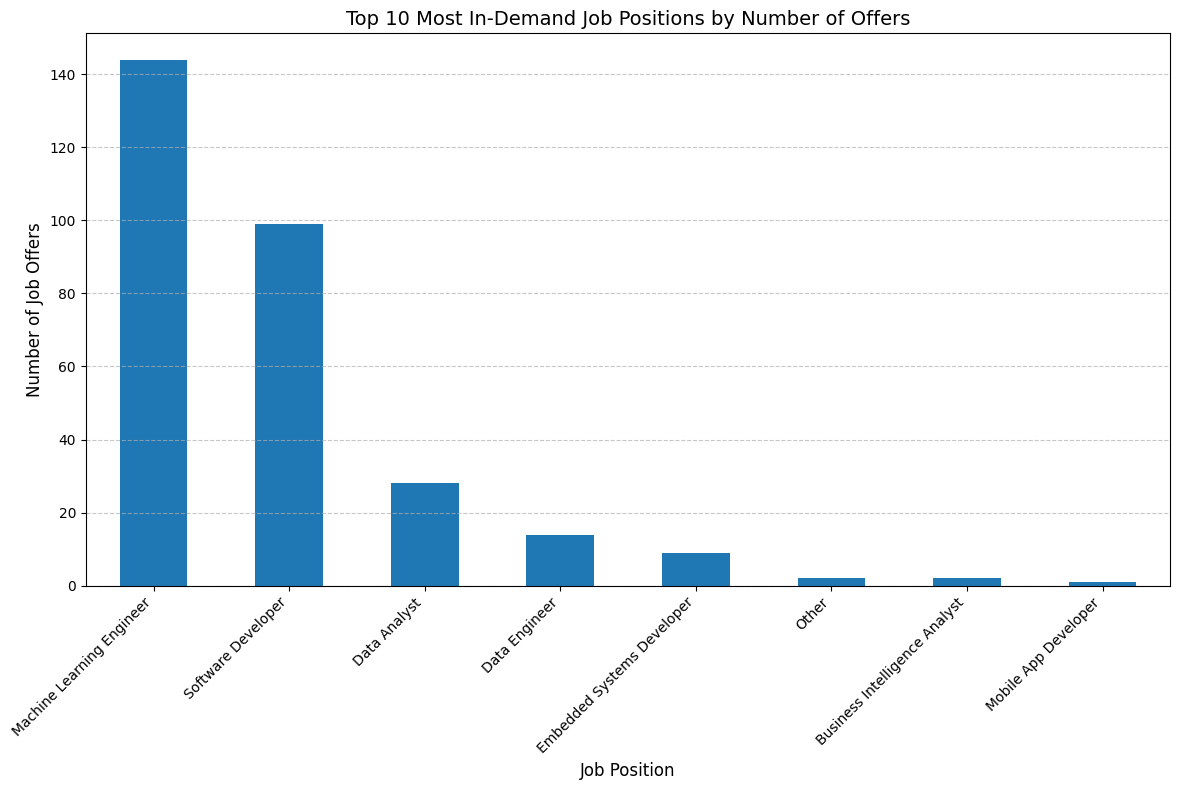

In [26]:
import matplotlib.pyplot as plt

# Count job occurrences
popular_jobs = job_details['Refined Standardized Position'].value_counts()

# Plot the data
plt.figure(figsize=(12, 8))  # Increase figure size for better visibility
popular_jobs.head(10).plot(kind='bar', legend=False)  # Remove unnecessary legend
plt.title("Top 10 Most In-Demand Job Positions by Number of Offers", fontsize=14)
plt.xlabel("Job Position", fontsize=12)
plt.ylabel("Number of Job Offers", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)  # Rotate x-axis labels and align them
plt.yticks(fontsize=10)  # Adjust font size for y-axis ticks
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add horizontal gridlines for better readability
plt.tight_layout()  # Adjust layout to avoid clipping
plt.show()

In [33]:
pip install adjustText

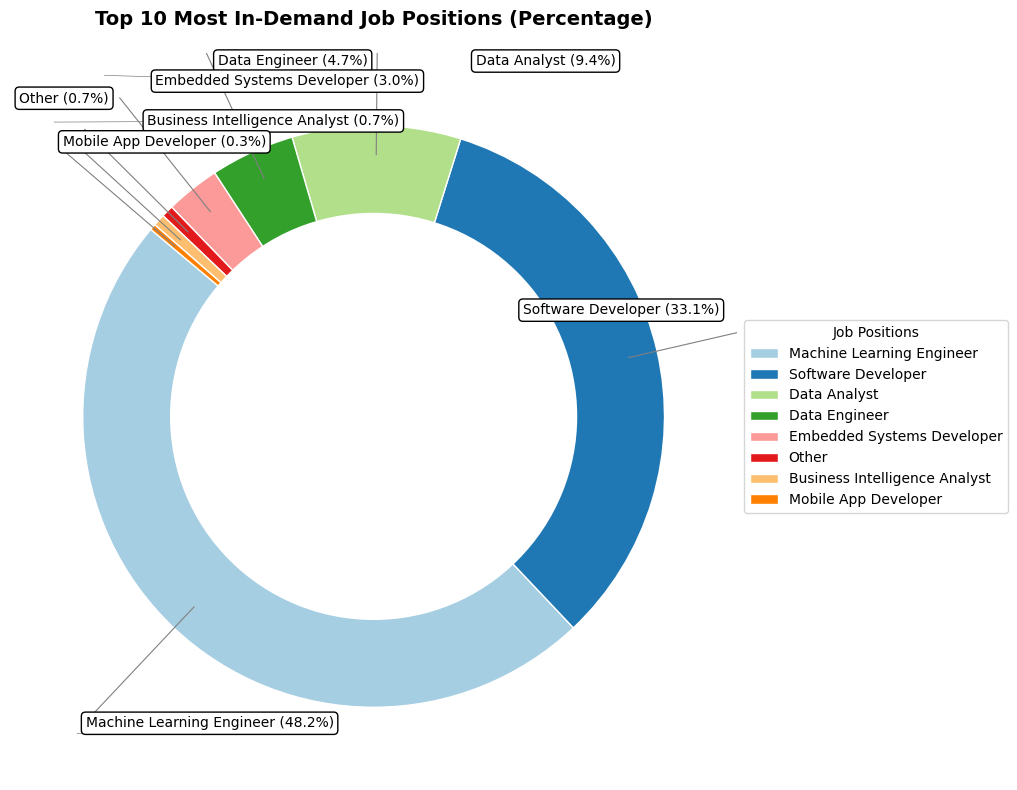

In [37]:
import matplotlib.pyplot as plt
import math
from adjustText import adjust_text

# Data preparation
top_10_jobs = popular_jobs.head(10)
labels = top_10_jobs.index
sizes = top_10_jobs.values

# Create the pie chart
plt.figure(figsize=(10, 8))
colors = plt.cm.Paired(range(len(labels)))

# Plot pie chart
wedges, texts = plt.pie(
    sizes,
    labels=None,  # Hide labels from the slices
    startangle=140,
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1},
)

# Add external labels with lines and percentages
texts_to_adjust = []  # Collect text objects for adjustment
bbox_props = dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="white")
for i, (wedge, pct) in enumerate(zip(wedges, sizes / sizes.sum() * 100)):
    angle = (wedge.theta2 - wedge.theta1) / 2. + wedge.theta1
    x = 1.5 * math.cos(math.radians(angle))  # Position for labels
    y = 1.5 * math.sin(math.radians(angle))
    label_text = f"{labels[i]} ({pct:.1f}%)"
    text = plt.text(x, y, label_text, horizontalalignment="center", bbox=bbox_props, fontsize=10)
    texts_to_adjust.append(text)

    # Draw a line from the pie slice to the label
    line_x = [0.9 * math.cos(math.radians(angle)), 1.4 * math.cos(math.radians(angle))]
    line_y = [0.9 * math.sin(math.radians(angle)), 1.4 * math.sin(math.radians(angle))]
    plt.plot(line_x, line_y, color="gray", lw=0.8)

# Adjust text positions to avoid overlap
adjust_text(texts_to_adjust, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))

# Add a center circle for a donut chart
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
plt.gca().add_artist(centre_circle)

# Title and legend
plt.title("Top 10 Most In-Demand Job Positions (Percentage)", fontsize=14, weight='bold', pad=20)
plt.legend(
    wedges,
    labels,
    title="Job Positions",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=10
)

plt.tight_layout()
plt.show()


##3.2 Find the Highest-Paying Job and Plot a Graph

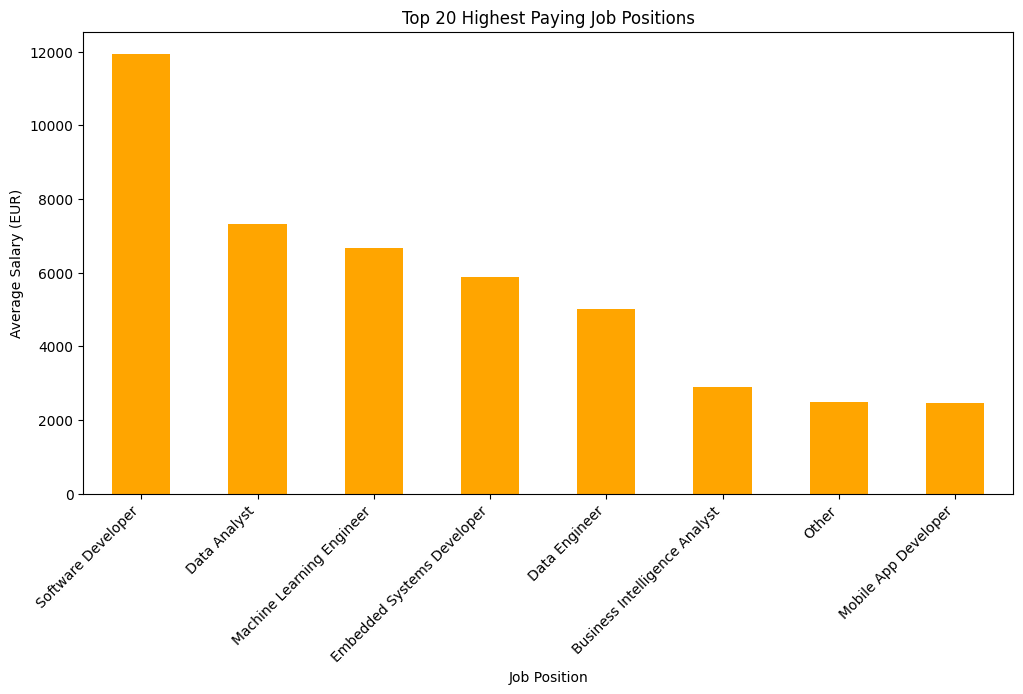

In [59]:
job_details['Average Salary (EUR)'] = pd.to_numeric(job_details['Average Salary (EUR)'], errors='coerce')

highest_paying_jobs = (
    job_details.groupby('Refined Standardized Position')['Average Salary (EUR)']
    .max()
    .sort_values(ascending=False)
)

# Plot the top 20 highest-paying positions
plt.figure(figsize=(12, 6))
highest_paying_jobs.head(20).plot(kind='bar', color='orange')
plt.title("Top 20 Highest Paying Job Positions")
plt.xlabel("Job Position")
plt.ylabel("Average Salary (EUR)")
plt.xticks(rotation=45, ha='right')
plt.show()



##3.3 Find the Most-Required Skills/Tools

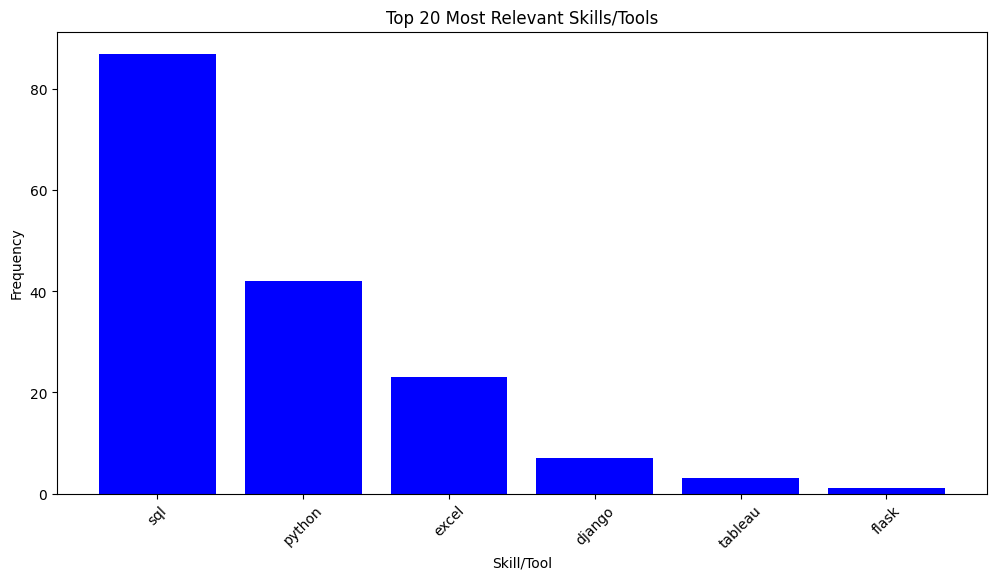

In [68]:
# Expanded stopword list
custom_stopwords.update({
    'requirements', 'technical', 'month', 'offer', 'office',
    'information', 'opportunity', 'years', 'ensure', 'training',
    'join', 'gross', 'software', 'environment', 'english',
    'processes', 'group', 'tax', 'support', 'product'
})

# Updated function to extract only actionable skills/tools
def extract_relevant_skills(description, predefined_skills):
    # Tokenize and remove special characters
    words = re.findall(r'\b\w+\b', description.lower())
    # Filter by predefined skills/tools
    skills = [word for word in words if word in predefined_skills]
    return skills

# Define a list of predefined skills/tools
predefined_skills = [
    'python', 'sql', 'excel', 'tableau', 'power bi', 'machine learning',
    'deep learning', 'tensorflow', 'pandas', 'numpy', 'scikit-learn',
    'django', 'flask', 'big data', 'data analysis', 'project management'
]

# Apply the function to extract actionable skills/tools
job_details['Skills'] = job_details['Job Description'].apply(lambda x: extract_relevant_skills(x, predefined_skills))

# Flatten and count occurrences
all_skills = sum(job_details['Skills'], [])
skill_counts = Counter(all_skills)

# Plot refined results
most_common_skills = pd.DataFrame(skill_counts.most_common(20), columns=['Skill', 'Count'])
plt.figure(figsize=(12, 6))
plt.bar(most_common_skills['Skill'], most_common_skills['Count'], color='blue')
plt.title("Top 20 Most Relevant Skills/Tools")
plt.xlabel("Skill/Tool")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()


In [74]:
# Specify the columns to retain
columns_to_keep = ['Job Description', 'Average Salary (EUR)', 'Job Position Original', 'Refined Standardized Position']

# Retain only the specified columns
job_details = job_details[columns_to_keep]

# Display the updated DataFrame
print(job_details.head())


                                     Job Description  Average Salary (EUR)  \
0  Job Describe\nProvide Technical Support to Hot...                1900.0   
1  Why is this the best job for the programmer?\n...                4000.0   
2  Why is this the best job for the programmer?\n...                4000.0   
3  Why is this the best job for the programmer?\n...                4000.0   
4  The nature of the work\nWe are looking for vir...                6675.0   

   Job Position Original Refined Standardized Position  
0  IT Support Specialist     Machine Learning Engineer  
1  Full Stack Programmer            Software Developer  
2  Full Stack Programmer            Software Developer  
3  Full Stack Programmer            Software Developer  
4      virtual assistant     Machine Learning Engineer  


1. Correct positions list, diffirent speciality. We need to make cleaning and correct name of this jobs.
2. Than find most popular position offer and plot a graph
3. Than Find  highest pay job and plot graph
4. I need to check Description, and merge most simmilar to one. To minimase range.
5. Than i need to find most looking requrements skills / tools. So need to find what to study


In [76]:
job_details_to_csv = job_details.to_csv('Final.csv', index=False)

In [75]:
# Save intermediate backup
timestamp = pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')
job_details.to_pickle(f'/content/Final_{timestamp}.pkl')